In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option("display.max_columns", None)

In [3]:
df = pd.read_csv("../dataset/Cloud_Anomaly_Dataset.csv")

In [4]:
df.head()

,vm_id,timestamp,cpu_usage,memory_usage,network_traffic,power_consumption,num_executed_instructions,execution_time,energy_efficiency,task_type,task_priority,task_status,Anomaly status
0,c5215826-6237-4a33-9312-72c1df909881,25-01-2023 09:10,54.881350,78.950861,164.775973,287.808986,7527.0,69.345575,0.553589,network,medium,waiting,0
1,29690bc6-1f34-403b-b509-a1ecb1834fb8,26-01-2023 04:46,71.518937,29.901883,NaN,362.273569,5348.0,41.396040,0.349856,io,high,completed,0
2,2e55abc3-5bad-46cb-b445-a577f5e9bf2a,13-01-2023 23:39,NaN,92.709195,203.674847,231.467903,5483.0,24.602549,0.796277,io,medium,completed,0
3,ea8455b0-251c-4470-b7ea-8d40476e3434,14-01-2023 19:59,79.172504,2.972252,926.374030,173.559325,8644.0,55.702673,0.779499,compute,medium,completed,0
4,fd28310b-be6f-4320-a664-de02274993d9,18-01-2023 11:22,87.001215,46.620176,437.188115,77.054702,9427.0,NaN,0.207164,NaN,low,waiting,0


In [5]:
df.shape

(277570, 13)

In [6]:
df.columns

Index(['vm_id', 'timestamp', 'cpu_usage', 'memory_usage', 'network_traffic',
       'power_consumption', 'num_executed_instructions', 'execution_time',
       'energy_efficiency', 'task_type', 'task_priority', 'task_status',
       'Anomaly status'],
      dtype='str')

In [7]:
df.rename(columns={"Anomaly status": "anomaly_status"}, inplace=True)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 277570 entries, 0 to 277569
Data columns (total 13 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   vm_id                      249595 non-null  str    
 1   timestamp                  277570 non-null  str    
 2   cpu_usage                  250130 non-null  float64
 3   memory_usage               249775 non-null  float64
 4   network_traffic            249725 non-null  float64
 5   power_consumption          250018 non-null  float64
 6   num_executed_instructions  249637 non-null  float64
 7   execution_time             249960 non-null  float64
 8   energy_efficiency          249616 non-null  float64
 9   task_type                  249580 non-null  str    
 10  task_priority              249674 non-null  str    
 11  task_status                249621 non-null  str    
 12  anomaly_status             277570 non-null  int64  
dtypes: float64(7), int64(1), str(5)
memory u

In [9]:
df.describe()

,cpu_usage,memory_usage,network_traffic,power_consumption,num_executed_instructions,execution_time,energy_efficiency,anomaly_status
count,250130.000000,249775.000000,249725.000000,250018.000000,249637.000000,249960.000000,249616.000000,277570.000000
mean,50.013258,49.967249,500.554083,249.987238,5002.490284,50.011964,0.500369,0.059999
std,28.895806,28.879090,288.787794,144.662676,2882.806422,28.837634,0.288547,0.237486
min,0.000071,0.000016,0.002542,0.000802,0.000000,0.000172,0.000004,0.000000
25%,24.880023,24.965105,250.298114,124.199907,2506.000000,25.098016,0.250375,0.000000
50%,50.023806,49.912051,500.736963,250.397212,5000.000000,50.005593,0.500834,0.000000
75%,75.097896,74.960052,750.720026,375.485305,7499.000000,75.043715,0.750112,0.000000
max,99.999171,99.999907,999.998686,499.998819,9999.000000,99.998831,0.999994,1.000000


In [10]:
df.isnull().sum()

vm_id                        27975
timestamp                        0
cpu_usage                    27440
memory_usage                 27795
network_traffic              27845
power_consumption            27552
num_executed_instructions    27933
execution_time               27610
energy_efficiency            27954
task_type                    27990
task_priority                27896
task_status                  27949
anomaly_status                   0
dtype: int64

In [11]:
df.isnull().all(axis=1).sum()

np.int64(0)

In [12]:
df["anomaly_status"].value_counts()

anomaly_status
0    260916
1     16654
Name: count, dtype: int64

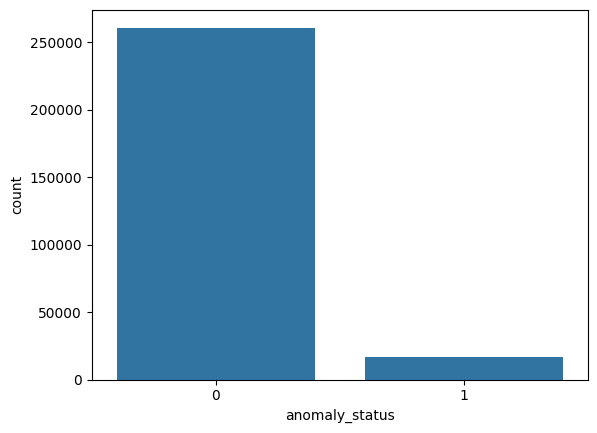

In [13]:
sns.countplot(x="anomaly_status", data=df)
plt.show()

In [14]:
print("task_type values:")
print(df["task_type"].unique())

print("task_priority values:")
print(df["task_priority"].unique())

print("task_status values:")
print(df["task_status"].unique())

task_type values:
<StringArray>
['network', 'io', 'compute', nan]
Length: 4, dtype: str
task_priority values:
<StringArray>
['medium', 'high', 'low', nan]
Length: 4, dtype: str
task_status values:
<StringArray>
['waiting', 'completed', 'running', nan]
Length: 4, dtype: str


In [15]:
df["vm_id"].nunique()

249595

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df.drop_duplicates(inplace=True)

In [18]:
df["timestamp"].head()

0    25-01-2023 09:10
1    26-01-2023 04:46
2    13-01-2023 23:39
3    14-01-2023 19:59
4    18-01-2023 11:22
Name: timestamp, dtype: str

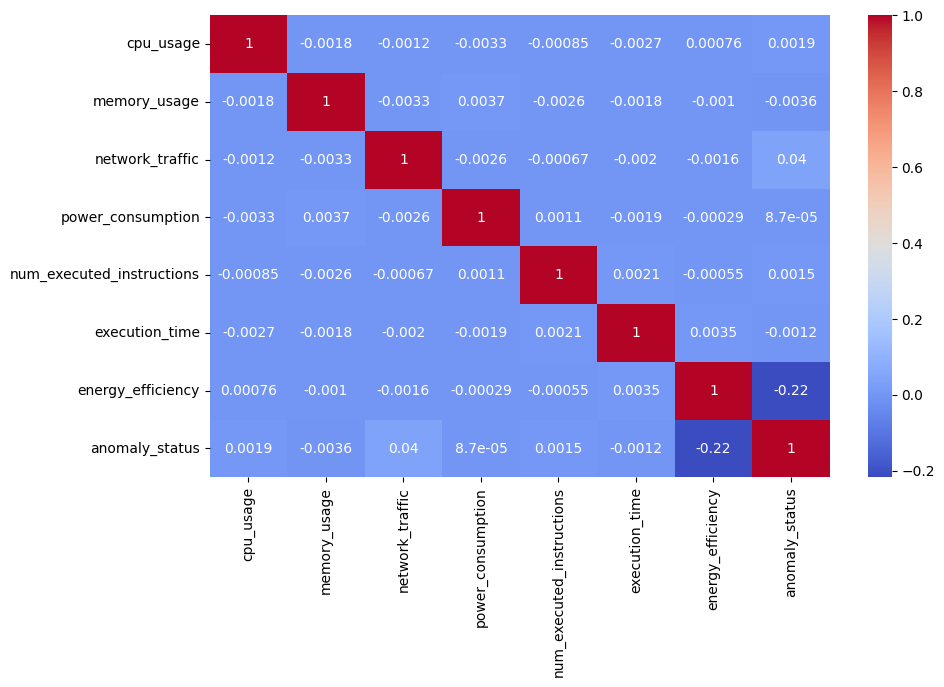

In [19]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

In [20]:
df = df.dropna(subset=["vm_id"])

In [21]:
df["vm_id"].isnull().sum()

np.int64(0)

In [22]:
df["timestamp"] = pd.to_datetime(
    df["timestamp"],
    format="%d-%m-%Y %H:%M"
)

In [23]:
df["timestamp"].head()

0   2023-01-25 09:10:00
1   2023-01-26 04:46:00
2   2023-01-13 23:39:00
3   2023-01-14 19:59:00
4   2023-01-18 11:22:00
Name: timestamp, dtype: datetime64[us]

In [24]:
df["hour"] = df["timestamp"].dt.hour

In [25]:
df["day_of_week"] = df["timestamp"].dt.dayofweek

In [26]:
df["month"] = df["timestamp"].dt.month

In [27]:
df.drop(columns=["timestamp"], inplace=True)

In [28]:
num_cols = [
    "cpu_usage",
    "memory_usage",
    "network_traffic",
    "power_consumption",
    "num_executed_instructions",
    "execution_time",
    "energy_efficiency"
]

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [29]:
cat_cols = [
    "task_type",
    "task_priority",
    "task_status"
]

for col in cat_cols:
    df[col] = df[col].fillna("unknown")

In [30]:
df.isnull().sum()

vm_id                        0
cpu_usage                    0
memory_usage                 0
network_traffic              0
power_consumption            0
num_executed_instructions    0
execution_time               0
energy_efficiency            0
task_type                    0
task_priority                0
task_status                  0
anomaly_status               0
hour                         0
day_of_week                  0
month                        0
dtype: int64

In [31]:
df["cpu_memory_ratio"] = df["cpu_usage"] / (df["memory_usage"] + 1)

In [32]:
df["network_cpu_ratio"] = df["network_traffic"] / (df["cpu_usage"] + 1)

In [33]:
df["power_cpu_ratio"] = df["power_consumption"] / (df["cpu_usage"] + 1)

In [34]:
df["instruction_rate"] = df["num_executed_instructions"] / (df["execution_time"] + 1)

In [35]:
df["cpu_instruction_ratio"] = df["cpu_usage"] / (df["num_executed_instructions"] + 1)

In [36]:
df["network_instruction_ratio"] = df["network_traffic"] / (df["num_executed_instructions"] + 1)

In [37]:
df.head()

,vm_id,cpu_usage,memory_usage,network_traffic,power_consumption,num_executed_instructions,execution_time,energy_efficiency,task_type,task_priority,task_status,anomaly_status,hour,day_of_week,month,cpu_memory_ratio,network_cpu_ratio,power_cpu_ratio,instruction_rate,cpu_instruction_ratio,network_instruction_ratio
0,c5215826-6237-4a33-9312-72c1df909881,54.881350,78.950861,164.775973,287.808986,7527.0,69.345575,0.553589,network,medium,waiting,0,9,2,1,0.686439,2.948676,5.150358,107.000334,0.007290,0.021888
1,29690bc6-1f34-403b-b509-a1ecb1834fb8,71.518937,29.901883,501.031549,362.273569,5348.0,41.396040,0.349856,io,high,completed,0,4,3,1,2.314388,6.908975,4.995572,126.143858,0.013371,0.093668
2,2e55abc3-5bad-46cb-b445-a577f5e9bf2a,49.977558,92.709195,203.674847,231.467903,5483.0,24.602549,0.796277,io,medium,completed,0,23,4,1,0.533326,3.995383,4.540584,214.158365,0.009113,0.037140
3,ea8455b0-251c-4470-b7ea-8d40476e3434,79.172504,2.972252,926.374030,173.559325,8644.0,55.702673,0.779499,compute,medium,completed,0,19,5,1,19.931389,11.554760,2.164824,152.444314,0.009158,0.107157
4,fd28310b-be6f-4320-a664-de02274993d9,87.001215,46.620176,437.188115,77.054702,9427.0,50.089906,0.207164,unknown,low,waiting,0,11,2,1,1.826982,4.967978,0.875610,184.517859,0.009228,0.046371


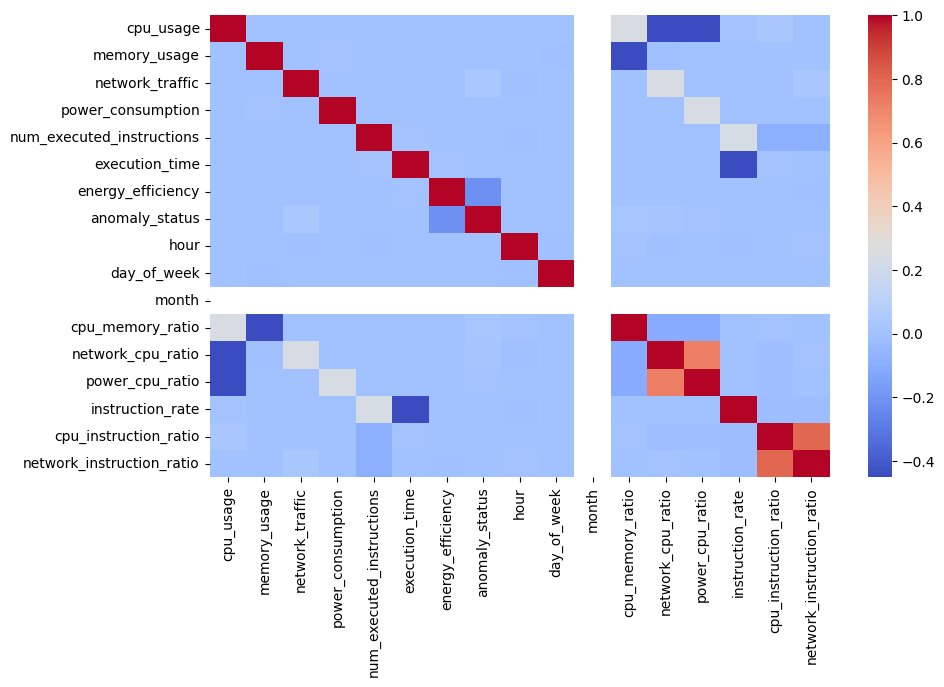

In [38]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.show()

In [39]:
df.drop(columns=["month"], inplace=True)

In [40]:
cat_cols = ["task_type", "task_priority", "task_status"]

In [41]:
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [42]:
df.head()

,vm_id,cpu_usage,memory_usage,network_traffic,power_consumption,num_executed_instructions,execution_time,energy_efficiency,anomaly_status,hour,day_of_week,cpu_memory_ratio,network_cpu_ratio,power_cpu_ratio,instruction_rate,cpu_instruction_ratio,network_instruction_ratio,task_type_io,task_type_network,task_type_unknown,task_priority_low,task_priority_medium,task_priority_unknown,task_status_running,task_status_unknown,task_status_waiting
0,c5215826-6237-4a33-9312-72c1df909881,54.881350,78.950861,164.775973,287.808986,7527.0,69.345575,0.553589,0,9,2,0.686439,2.948676,5.150358,107.000334,0.007290,0.021888,False,True,False,False,True,False,False,False,True
1,29690bc6-1f34-403b-b509-a1ecb1834fb8,71.518937,29.901883,501.031549,362.273569,5348.0,41.396040,0.349856,0,4,3,2.314388,6.908975,4.995572,126.143858,0.013371,0.093668,True,False,False,False,False,False,False,False,False
2,2e55abc3-5bad-46cb-b445-a577f5e9bf2a,49.977558,92.709195,203.674847,231.467903,5483.0,24.602549,0.796277,0,23,4,0.533326,3.995383,4.540584,214.158365,0.009113,0.037140,True,False,False,False,True,False,False,False,False
3,ea8455b0-251c-4470-b7ea-8d40476e3434,79.172504,2.972252,926.374030,173.559325,8644.0,55.702673,0.779499,0,19,5,19.931389,11.554760,2.164824,152.444314,0.009158,0.107157,False,False,False,False,True,False,False,False,False
4,fd28310b-be6f-4320-a664-de02274993d9,87.001215,46.620176,437.188115,77.054702,9427.0,50.089906,0.207164,0,11,2,1.826982,4.967978,0.875610,184.517859,0.009228,0.046371,False,False,True,True,False,False,False,False,True


In [43]:
df.shape

(249595, 26)

In [44]:
df.dtypes

vm_id                            str
cpu_usage                    float64
memory_usage                 float64
network_traffic              float64
power_consumption            float64
num_executed_instructions    float64
execution_time               float64
energy_efficiency            float64
anomaly_status                 int64
hour                           int32
day_of_week                    int32
cpu_memory_ratio             float64
network_cpu_ratio            float64
power_cpu_ratio              float64
instruction_rate             float64
cpu_instruction_ratio        float64
network_instruction_ratio    float64
task_type_io                    bool
task_type_network               bool
task_type_unknown               bool
task_priority_low               bool
task_priority_medium            bool
task_priority_unknown           bool
task_status_running             bool
task_status_unknown             bool
task_status_waiting             bool
dtype: object

In [45]:
df.drop(columns=["vm_id"], inplace=True)

In [46]:
df.columns

Index(['cpu_usage', 'memory_usage', 'network_traffic', 'power_consumption',
       'num_executed_instructions', 'execution_time', 'energy_efficiency',
       'anomaly_status', 'hour', 'day_of_week', 'cpu_memory_ratio',
       'network_cpu_ratio', 'power_cpu_ratio', 'instruction_rate',
       'cpu_instruction_ratio', 'network_instruction_ratio', 'task_type_io',
       'task_type_network', 'task_type_unknown', 'task_priority_low',
       'task_priority_medium', 'task_priority_unknown', 'task_status_running',
       'task_status_unknown', 'task_status_waiting'],
      dtype='str')

In [47]:
X = df.drop(columns=["anomaly_status"])
y = df["anomaly_status"]

In [48]:
print(X.shape)
print(y.shape)

(249595, 24)
(249595,)


In [49]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [50]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

anomaly_status
0    0.940108
1    0.059892
Name: proportion, dtype: float64
anomaly_status
0    0.940103
1    0.059897
Name: proportion, dtype: float64


In [51]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train,
    y_train
)

In [52]:
print(y_train_resampled.value_counts())

anomaly_status
0    187717
1    187717
Name: count, dtype: int64


In [53]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [54]:
rf_model.fit(X_train_resampled, y_train_resampled)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [55]:
y_pred = rf_model.predict(X_test)

In [56]:
y_prob = rf_model.predict_proba(X_test)[:,1]

In [57]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95     46929
           1       0.16      0.15      0.15      2990

    accuracy                           0.90     49919
   macro avg       0.55      0.55      0.55     49919
weighted avg       0.90      0.90      0.90     49919



In [58]:
confusion_matrix(y_test, y_pred)

array([[44551,  2378],
       [ 2553,   437]])

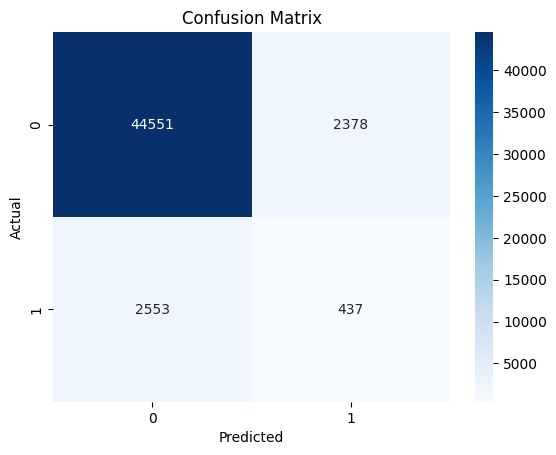

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [60]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

In [61]:
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [62]:
y_prob = rf_model.predict_proba(X_test)[:,1]

y_pred = (y_prob > 0.3).astype(int)

In [63]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97     46929
           1       0.14      0.00      0.01      2990

    accuracy                           0.94     49919
   macro avg       0.54      0.50      0.49     49919
weighted avg       0.89      0.94      0.91     49919



In [110]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=15,
    random_state=42
)

model.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [111]:
y_pred = model.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.70      0.82     46929
           1       0.17      0.96      0.29      2990

    accuracy                           0.71     49919
   macro avg       0.58      0.83      0.55     49919
weighted avg       0.95      0.71      0.79     49919



In [112]:
from sklearn.metrics import accuracy_score, recall_score

In [113]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

recall = recall_score(y_test, y_pred)
print("Recall:", recall)

Accuracy: 0.7146176806426411
Recall: 0.9558528428093646


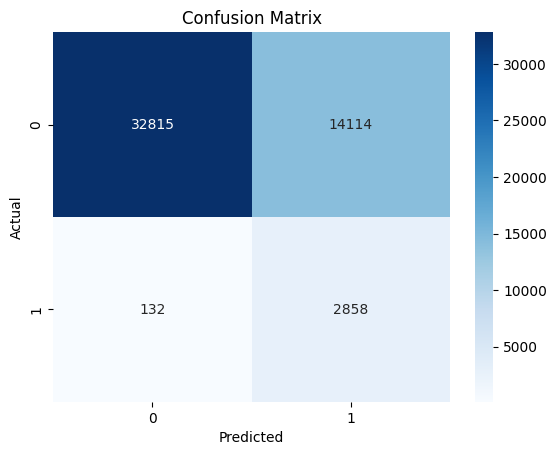

In [114]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [115]:
import shap

/Users/subin/Desktop/Cap/Project2/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [116]:
explainer = shap.TreeExplainer(model)

In [117]:
shap_values = explainer.shap_values(X_test)

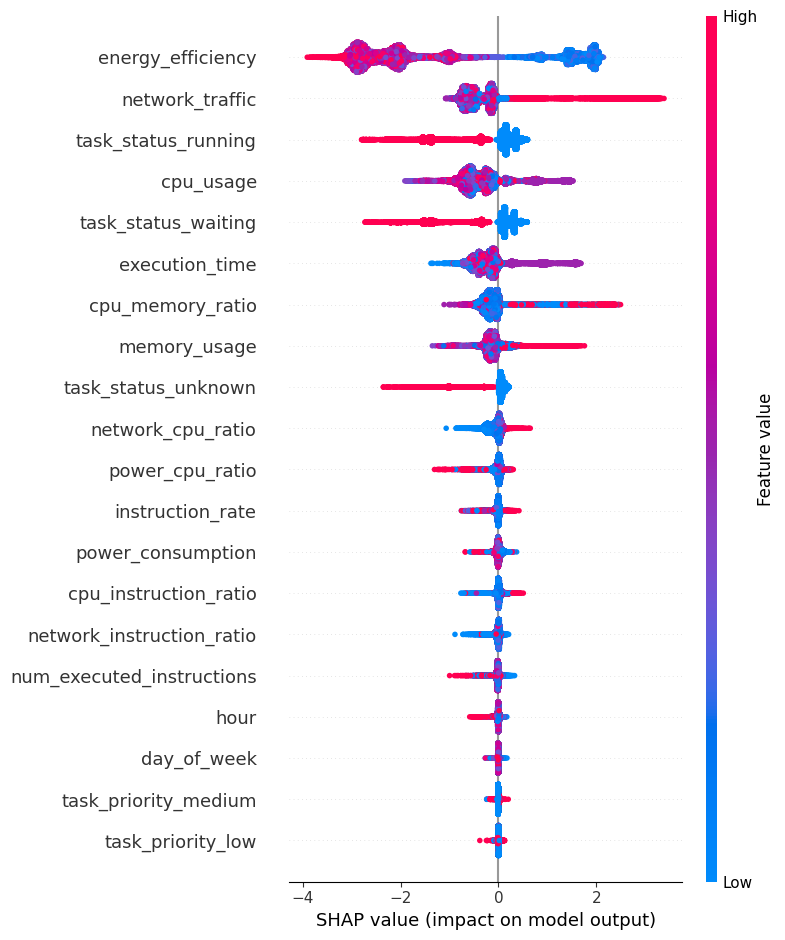

In [118]:
shap.summary_plot(shap_values, X_test)

In [119]:
anomaly_index = X_test[y_pred == 1].index[0]

In [123]:
sample = X_test.loc[[anomaly_index]]

In [124]:
sample_shap = explainer.shap_values(sample)

In [127]:
import pandas as pd

feature_contributions = pd.DataFrame({
    "feature": X_test.columns,
    "value": sample.values.flatten(),
    "shap_value": sample_shap.flatten()
})

feature_contributions["importance"] = feature_contributions["shap_value"].abs()

top_features = feature_contributions.sort_values(
    by="importance",
    ascending=False
).head(5)

print(top_features)

                feature      value  shap_value  importance
0             cpu_usage  49.977558    1.466338    1.466338
6     energy_efficiency   0.932343   -1.134109    1.134109
23  task_status_waiting      False    0.464347    0.464347
21  task_status_running      False    0.464109    0.464109
22  task_status_unknown      False    0.180586    0.180586


In [128]:
top_features_dict = top_features.to_dict(orient="records")
print(top_features_dict)

[{'feature': 'cpu_usage', 'value': 49.97755837, 'shap_value': 1.4663383960723877, 'importance': 1.4663383960723877}, {'feature': 'energy_efficiency', 'value': 0.932343076, 'shap_value': -1.1341094970703125, 'importance': 1.1341094970703125}, {'feature': 'task_status_waiting', 'value': False, 'shap_value': 0.4643471837043762, 'importance': 0.4643471837043762}, {'feature': 'task_status_running', 'value': False, 'shap_value': 0.46410882472991943, 'importance': 0.46410882472991943}, {'feature': 'task_status_unknown', 'value': False, 'shap_value': 0.18058590590953827, 'importance': 0.18058590590953827}]


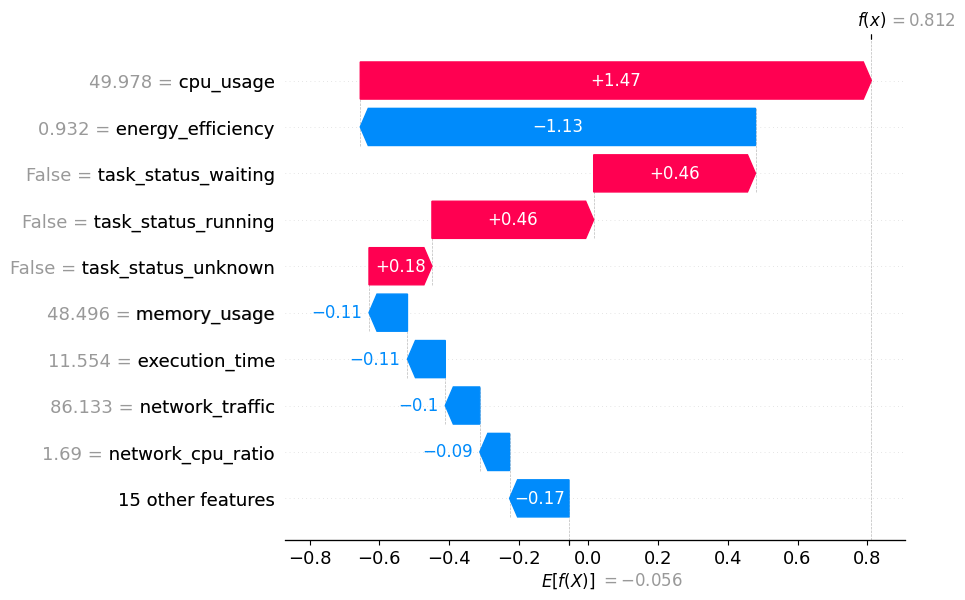

In [129]:
shap.plots.waterfall(
    shap.Explanation(
        values=sample_shap[0],
        base_values=explainer.expected_value,
        data=sample.iloc[0],
        feature_names=X_test.columns
    )
)

In [ ]:
import os
from dotenv import load_dotenv

load_dotenv()
os.environ["LANGCHAIN_API_KEY"] = os.getenv("LANGCHAIN_API_KEY")
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["USER_AGENT"] = "myagent"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

from langchain_groq import ChatGroq

llm = ChatGroq(model="llama-3.3-70b-versatile")

In [150]:
anomaly_index = X_test[y_pred == 1].index[0]

sample = X_test.loc[[anomaly_index]]

In [151]:
sample_shap = explainer.shap_values(sample)

In [152]:
import pandas as pd

feature_contributions = pd.DataFrame({
    "feature": X_test.columns,
    "value": sample.values.flatten(),
    "shap_value": sample_shap.flatten()
})

feature_contributions["importance"] = feature_contributions["shap_value"].abs()

top_features = feature_contributions.sort_values(
    by="importance",
    ascending=False
).head(5)

In [153]:
feature_text = ""

for _, row in top_features.iterrows():
    feature_text += f"{row['feature']} = {row['value']} (impact={row['shap_value']:.3f})\n"

In [154]:
from langchain_core.prompts import ChatPromptTemplate

prompt = ChatPromptTemplate.from_template(
"""
You are a cloud infrastructure monitoring expert.

An anomaly was detected in a virtual machine.

Top contributing features:

{features}

Explain why this VM behavior might indicate an anomaly in simple technical language.
"""
)

In [157]:
print(feature_text)

cpu_usage = 49.97755837 (impact=1.466)
energy_efficiency = 0.932343076 (impact=-1.134)
task_status_waiting = False (impact=0.464)
task_status_running = False (impact=0.464)
task_status_unknown = False (impact=0.181)



In [155]:
chain = prompt | llm

In [156]:
response = chain.invoke({
    "features": feature_text
})

print(response.content)

This virtual machine (VM) is behaving abnormally due to high CPU usage. The CPU usage is at 49.98%, which is unusually high. This suggests that the VM is working very hard, possibly due to a resource-intensive process or application running on it.

At the same time, the energy efficiency of the VM is relatively low (0.93), which means it's not using its resources in the most efficient way. This could be related to the high CPU usage, as the VM is consuming more energy than expected.

The task status indicators (waiting, running, unknown) are all set to False, which means there aren't any tasks waiting or running in an unknown state. This suggests that the high CPU usage is not due to a backlog of tasks or unknown processes.

Overall, the combination of high CPU usage and low energy efficiency suggests that something unusual is happening on this VM, which is why it's being flagged as an anomaly. It's possible that a process or application is malfunctioning or consuming too many resource